Um exercício de aprendizado de máquina para treinar um modelo que diferencia gatos de cachorros usando TensorFlow.

## ⚙️ Criando uma sessão TensorFlow

O código permite escolher entre usar TPU ou CPU como backend para executar a inferência.

In [ ]:
# ============================================================
# CÉLULA 1 — Imports
# PyTorch + torchvision: nativos no Colab, sem conflitos.
# VS Code: pip install torch torchvision pillow matplotlib
# ============================================================
import torch
import torchvision
import numpy as np
from PIL import Image, ImageDraw
from IPython import display
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import colorsys, io

# Verifica disponibilidade de GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"✅ PyTorch: {torch.__version__}")
print(f"✅ Torchvision: {torchvision.__version__}")
print(f"✅ Dispositivo: {device}")


✅ PyTorch: 2.11.0+cpu
✅ Torchvision: 0.26.0+cpu
✅ Dispositivo: cpu


## 📂 Carregando uma imagem

O trecho mostra como baixar e abrir uma imagem para ser usada no processo de segmentação.
- O notebook baixa uma imagem da web e a salva como `test.jpg`
- Converte a imagem em um array NumPy para processamento
- Exibe a imagem carregada diretamente no notebook

🗑️  Arquivo anterior removido.
⏳ Tentando: https://upload.wikimedia.org/wikipedia/commons/0/08/Kitano_S...
   ❌ Falhou: HTTP Error 403: Forbidden
⏳ Tentando: https://images.unsplash.com/photo-1477959858617-67f85cf4f1df...
   ✅ Baixado com sucesso! (360,463 bytes)

📐 Dimensões: 1280 x 787 px


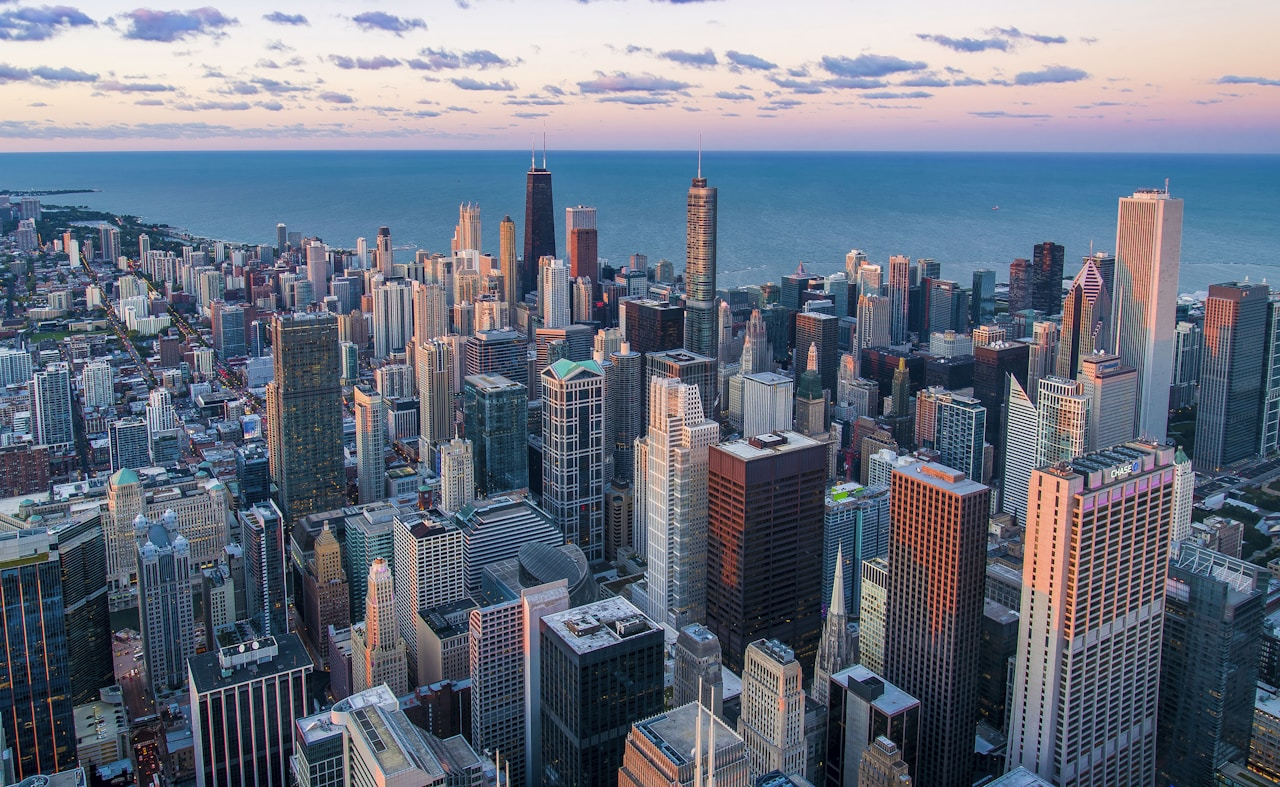

In [ ]:
# ============================================================
# CÉLULA 2 — Download robusto da imagem com diagnóstico
# ============================================================
import os
import urllib.request
from PIL import Image
from IPython import display

image_path = 'test.jpg'

# --- Remove arquivo corrompido se existir ---
if os.path.exists(image_path):
    os.remove(image_path)
    print("🗑️  Arquivo anterior removido.")

# URLs alternativas (caso a principal falhe)
urls = [
    'https://upload.wikimedia.org/wikipedia/commons/0/08/Kitano_Street_Kobe01s5s4110.jpg',
    'https://images.unsplash.com/photo-1477959858617-67f85cf4f1df?w=1280',
    'https://upload.wikimedia.org/wikipedia/commons/thumb/4/47/PNG_transparency_demonstration_1.png/280px-PNG_transparency_demonstration_1.png',
]

downloaded = False
for url in urls:
    try:
        print(f"⏳ Tentando: {url[:60]}...")
        urllib.request.urlretrieve(url, image_path)

        # Valida se o arquivo é uma imagem real
        size = os.path.getsize(image_path)
        if size < 1000:
            print(f"   ⚠️  Arquivo muito pequeno ({size} bytes). Tentando próxima URL.")
            continue

        img_test = Image.open(image_path)
        img_test.verify()  # Verifica integridade sem carregar na memória
        print(f"   ✅ Baixado com sucesso! ({size:,} bytes)")
        downloaded = True
        break

    except Exception as e:
        print(f"   ❌ Falhou: {e}")
        if os.path.exists(image_path):
            os.remove(image_path)

if not downloaded:
    raise RuntimeError("Nenhuma URL funcionou. Verifique a conexão ou faça upload manual de uma imagem.")

# Reabre após verify() (verify() fecha o arquivo internamente)
image_pil = Image.open(image_path).convert('RGB')
width, height = image_pil.size

print(f"\n📐 Dimensões: {width} x {height} px")
display.display(display.Image(image_path, width=800))

## 📂 Carregando o modelo pré-treinado

O trecho mostra como importar os pesos do Mask R‑CNN treinado no COCO dataset, diretamente de um bucket público do Google Cloud.

### 📌 O que acontece aqui

- `saved_model_dir` → aponta para o diretório onde estão os pesos do modelo
- `tf.saved_model.load(...)` → carrega o modelo na sessão TensorFlow criada anteriormente
- Mensagem INFO → confirma que os parâmetros foram restaurados com sucesso

In [ ]:
# ============================================================
# CÉLULA 3 — Carregamento do Mask R-CNN pré-treinado no COCO
#
# torchvision.models.detection.maskrcnn_resnet50_fpn é o
# modelo oficial da PyTorch, treinado no COCO 2017.
# weights="DEFAULT" baixa automaticamente os pesos oficiais.
# Funciona no Colab e VS Code sem nenhum conflito.
# ============================================================
from torchvision.models.detection import maskrcnn_resnet50_fpn, MaskRCNN_ResNet50_FPN_Weights

print("⏳ Carregando Mask R-CNN pré-treinado no COCO...")

weights = MaskRCNN_ResNet50_FPN_Weights.DEFAULT
model   = maskrcnn_resnet50_fpn(weights=weights)
model   = model.to(device)
model.eval()  # Modo inferência: desativa dropout e batch norm de treino

print("✅ Modelo carregado!")
print(f"   Backbone: ResNet-50 + FPN")
print(f"   Dataset de treino: COCO 2017 (80 classes)")

⏳ Carregando Mask R-CNN pré-treinado no COCO...
Downloading: "https://download.pytorch.org/models/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth" to /root/.cache/torch/hub/checkpoints/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth


100%|██████████| 170M/170M [00:00<00:00, 220MB/s]


✅ Modelo carregado!
   Backbone: ResNet-50 + FPN
   Dataset de treino: COCO 2017 (80 classes)


## 🧩 Segmentação de instâncias e predições

O código executa o modelo e processa os resultados.

### 📌 O que acontece aqui

- `infer(...)` → executa a inferência no modelo, retornando:
  - número de detecções
  - caixas delimitadoras
  - classes previstas
  - scores de confiança
  - máscaras de segmentação
- **Processamento dos resultados:**
  - Remove dimensões extras (`np.squeeze`)
  - Ajusta coordenadas das caixas delimitadoras
  - Converte máscaras em segmentações utilizáveis

In [ ]:
# ============================================================
# CÉLULA 4 — Pré-processamento e inferência
#
# O torchvision espera um tensor float32 normalizado [0, 1]
# com shape (C, H, W). A transform DEFAULT já faz isso.
# ============================================================

# Aplica as transforms recomendadas pelo modelo
preprocess = weights.transforms()
img_tensor = preprocess(image_pil).to(device)  # Shape: (3, H, W)

print("⏳ Executando inferência...")

with torch.no_grad():
    # O modelo recebe uma lista de tensores e retorna uma lista de dicts
    predictions = model([img_tensor])

pred = predictions[0]  # Pega o resultado da primeira (única) imagem

# Extrai os tensores de resultado
boxes   = pred['boxes'].cpu().numpy()    # (N, 4) — [x1, y1, x2, y2]
labels  = pred['labels'].cpu().numpy()   # (N,)   — índice da classe COCO
scores  = pred['scores'].cpu().numpy()   # (N,)   — confiança [0, 1]
masks   = pred['masks'].cpu().numpy()    # (N, 1, H, W) — prob por pixel

print(f"✅ Inferência concluída!")
print(f"   Total de detecções (brutas): {len(scores)}")

⏳ Executando inferência...
✅ Inferência concluída!
   Total de detecções (brutas): 45


## 🖼️ Visualização das detecções

O código define parâmetros e chama a função utilitária para desenhar caixas e máscaras sobre a imagem.

In [ ]:
# ============================================================
# CÉLULA 5 — Classes do COCO (80 categorias)
# ============================================================

COCO_CLASSES = [
    '__background__', 'person', 'bicycle', 'car', 'motorcycle', 'airplane',
    'bus', 'train', 'truck', 'boat', 'traffic light', 'fire hydrant',
    'stop sign', 'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse',
    'sheep', 'cow', 'elephant', 'bear', 'zebra', 'giraffe', 'backpack',
    'umbrella', 'handbag', 'tie', 'suitcase', 'frisbee', 'skis',
    'snowboard', 'sports ball', 'kite', 'baseball bat', 'baseball glove',
    'skateboard', 'surfboard', 'tennis racket', 'bottle', 'wine glass',
    'cup', 'fork', 'knife', 'spoon', 'bowl', 'banana', 'apple', 'sandwich',
    'orange', 'broccoli', 'carrot', 'hot dog', 'pizza', 'donut', 'cake',
    'chair', 'couch', 'potted plant', 'bed', 'dining table', 'toilet', 'tv',
    'laptop', 'mouse', 'remote', 'keyboard', 'cell phone', 'microwave',
    'oven', 'toaster', 'sink', 'refrigerator', 'book', 'clock', 'vase',
    'scissors', 'teddy bear', 'hair drier', 'toothbrush'
]

## 🖼️ Visualização das detecções — Execução

In [ ]:
# ============================================================
# CÉLULA 6 — Funções de visualização
# ============================================================

def generate_colors(n):
    """Gera n cores distintas e vibrantes via HSV."""
    return [
        tuple(int(c * 255) for c in colorsys.hsv_to_rgb(i / max(n, 1), 0.85, 0.95))
        for i in range(n)
    ]


def apply_mask(image_array, mask_2d, color, alpha=0.45):
    """
    Aplica máscara semitransparente colorida sobre a imagem.
    mask_2d: array booleano (H, W)
    color: tupla RGB (0-255)
    alpha: opacidade da máscara
    """
    out = image_array.copy().astype(np.float32)
    for c, val in enumerate(color):
        out[:, :, c] = np.where(mask_2d, out[:, :, c] * (1 - alpha) + val * alpha, out[:, :, c])
    return np.clip(out, 0, 255).astype(np.uint8)


def draw_detections(image_pil, boxes, labels, scores, masks,
                    min_score=0.5, max_boxes=50, mask_threshold=0.5):
    """
    Desenha bounding boxes, labels, scores e máscaras de segmentação.

    Parâmetros:
        image_pil     : imagem PIL original
        boxes         : array (N, 4) com [x1, y1, x2, y2]
        labels        : array (N,) com índices de classe COCO
        scores        : array (N,) com scores de confiança
        masks         : array (N, 1, H, W) com probabilidades por pixel
        min_score     : filtra detecções abaixo deste score
        max_boxes     : limita o número de detecções desenhadas
        mask_threshold: limiar para binarizar a máscara (default 0.5)
    """
    # Filtra por score mínimo e limita quantidade
    valid = [i for i, s in enumerate(scores) if s >= min_score][:max_boxes]

    if not valid:
        print(f"⚠️  Nenhuma detecção com score >= {min_score}.")
        print(f"   Tente reduzir min_score_thresh (ex: 0.3).")
        return image_pil

    img_array = np.array(image_pil).copy()
    colors    = generate_colors(len(valid))

    for idx, (i, color) in enumerate(zip(valid, colors)):
        x1, y1, x2, y2 = [int(v) for v in boxes[i]]
        score     = scores[i]
        label_idx = labels[i]
        label_name = COCO_CLASSES[label_idx] if label_idx < len(COCO_CLASSES) else f'class_{label_idx}'

        # --- Aplica máscara de segmentação ---
        # masks[i] tem shape (1, H, W); binariza com threshold
        mask_2d = masks[i, 0] > mask_threshold  # Shape: (H, W)
        img_array = apply_mask(img_array, mask_2d, color, alpha=0.45)

        # --- Desenha bounding box (espessura 3px) ---
        pil_tmp = Image.fromarray(img_array)
        draw    = ImageDraw.Draw(pil_tmp)
        for t in range(3):
            draw.rectangle([x1+t, y1+t, x2-t, y2-t], outline=color)

        # --- Rótulo: "classe: score" ---
        label_text = f'{label_name}: {score:.2f}'
        text_bg_x2 = x1 + len(label_text) * 7
        text_y     = max(y1 - 18, 0)

        draw.rectangle([x1, text_y, text_bg_x2, text_y + 16], fill=color)
        draw.text((x1 + 2, text_y + 1), label_text, fill=(255, 255, 255))

        img_array = np.array(pil_tmp)

    print(f"✅ {len(valid)} detecções desenhadas (score >= {min_score})")
    return Image.fromarray(img_array)

📊 Detecções por score:
   [0] surfboard: 0.420
   [1] car: 0.385
   [2] traffic light: 0.284
   [3] car: 0.201
   [4] person: 0.191
   [5] person: 0.176
   [6] sports ball: 0.175
   [7] truck: 0.166
   [8] person: 0.160
   [9] truck: 0.149
⚠️  Nenhuma detecção com score >= 0.5.
   Tente reduzir min_score_thresh (ex: 0.3).


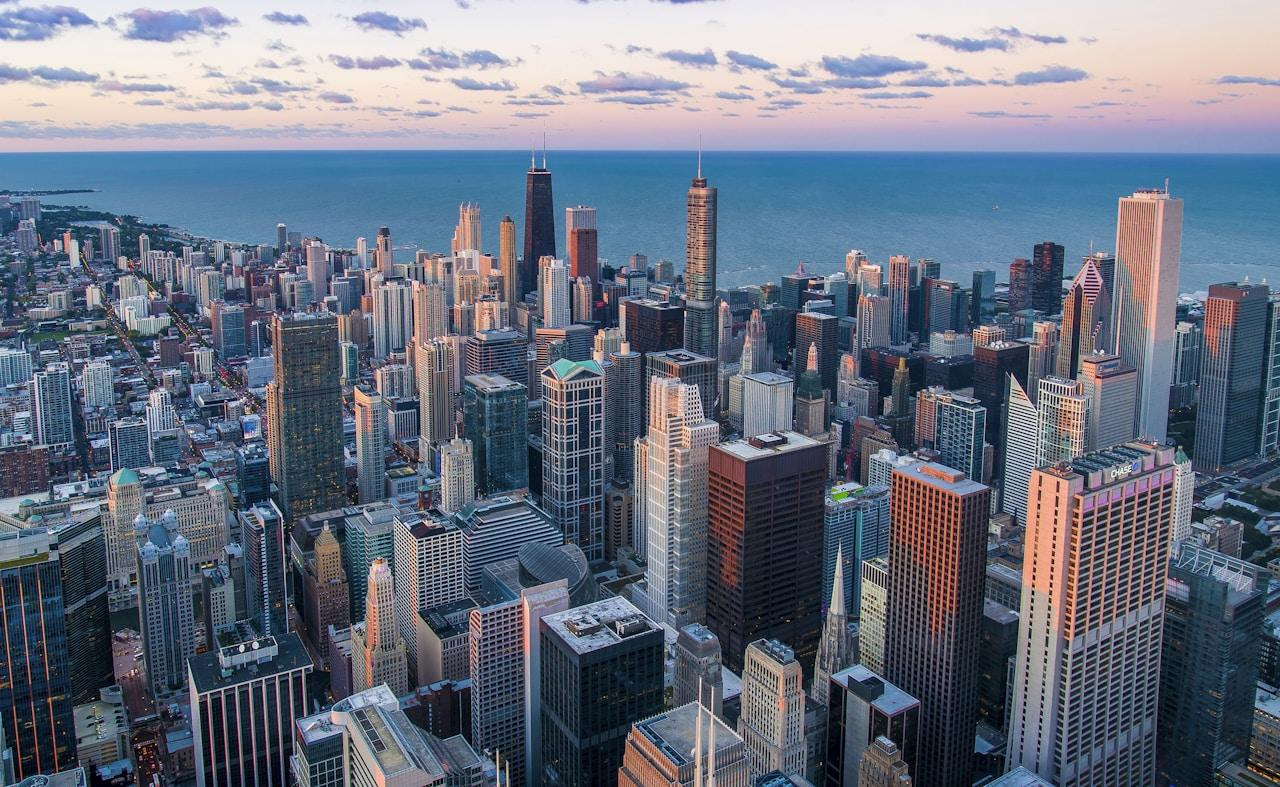

✅ Imagem salva em: test_results.jpg


In [ ]:
# ============================================================
# CÉLULA 7 — Parâmetros e execução da visualização
# ============================================================

min_score_thresh  = 0.5   # Mínimo de confiança (0.0 a 1.0)
max_boxes_to_draw = 50    # Máximo de objetos desenhados
mask_threshold    = 0.5   # Threshold de binarização das máscaras

# Exibe estatísticas das detecções antes de filtrar
print("📊 Detecções por score:")
for i, (lbl, sc) in enumerate(zip(labels[:10], scores[:10])):
    nome = COCO_CLASSES[lbl] if lbl < len(COCO_CLASSES) else f'class_{lbl}'
    print(f"   [{i}] {nome}: {sc:.3f}")

# Gera imagem anotada
result_image = draw_detections(
    image_pil      = image_pil,
    boxes          = boxes,
    labels         = labels,
    scores         = scores,
    masks          = masks,
    min_score      = min_score_thresh,
    max_boxes      = max_boxes_to_draw,
    mask_threshold = mask_threshold
)

# Salva e exibe
output_path = 'test_results.jpg'
result_image.save(output_path)

display.display(display.Image(output_path, width=1024))
print(f"✅ Imagem salva em: {output_path}")